Neste notebook será feita o pré-processamento dos dados referentes ao consumo e ao edifícios.
Será análisado a existência ou inexistência de missing values e será feito também a identificação e o tratamento dos outliers identificados.

# Dados Edifícios

## Missing Values

In [1]:
import geopandas as gpd

# Carregar o ficheiro
gdf = gpd.read_file(r"C:\Users\gabri\OneDrive\Ambiente de Trabalho\Milestone2\raw\edificios.gpkg", layer="ed12_polygons_all_with_heights_clean")

# Ver primeiras linhas
print(gdf.head())

# 🔹 Ver número de valores nulos por coluna
print("\nValores nulos por coluna:")
print(gdf.isnull().sum())

# 🔹 Ver percentagem de valores nulos
print("\nPercentagem de valores nulos (%):")
print((gdf.isnull().mean() * 100).round(2))

# 🔹 Ver linhas com algum valor nulo
print("\nLinhas com valores nulos:")
print(gdf[gdf.isnull().any(axis=1)])

# 🔹 Ver se existem geometrias inválidas ou nulas
print("\nGeometrias nulas:")
print(gdf[gdf.geometry.isnull()])

                  Layer  PaperSpace                 SubClasses Linetype  \
0  ED08_EDIF_PERMANENTE         NaN  AcDbEntity:AcDb3dPolyline     None   
1  ED08_EDIF_PERMANENTE         NaN  AcDbEntity:AcDb3dPolyline     None   
2  ED08_EDIF_PERMANENTE         NaN  AcDbEntity:AcDb3dPolyline     None   
3  ED08_EDIF_PERMANENTE         NaN  AcDbEntity:AcDb3dPolyline     None   
4  ED08_EDIF_PERMANENTE         NaN  AcDbEntity:AcDb3dPolyline     None   

  EntityHandle  Text                    src_file texto_limpo  area_m2  \
0         93D7  None  173255pl_ETRS89_PTTM06.dxf        None    31.74   
1         93E2  None  173255pl_ETRS89_PTTM06.dxf        None    44.85   
2         9400  None  173255pl_ETRS89_PTTM06.dxf        None   149.50   
3         940B  None  173255pl_ETRS89_PTTM06.dxf        None   153.76   
4         9415  None  173255pl_ETRS89_PTTM06.dxf        None    11.45   

               source_layer  ...  altura_edif_m  cota_topo_pt_m  \
0  ed08_edif_permanente_ply  ...           

In [2]:
# Ver valores iguais a zero
print("\nValores iguais a zero por coluna:")
print((gdf == 0).sum())

print("\nResumo geral:")
print(gdf.info())


Valores iguais a zero por coluna:
Layer                 0
PaperSpace            0
SubClasses            0
Linetype              0
EntityHandle          0
Text                  0
src_file              0
texto_limpo           0
area_m2               0
source_layer          0
polygon_id            1
altura_edif_m         0
cota_topo_pt_m        0
cota_terreno_est_m    0
dist_curva_min_m      0
n_points_height       0
qa_altura_negativa    0
qa_longe_curva        0
qa_rever              0
has_height            0
geometry              0
dtype: int64

Resumo geral:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 88649 entries, 0 to 88648
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Layer               88649 non-null  object  
 1   PaperSpace          0 non-null      float64 
 2   SubClasses          88649 non-null  object  
 3   Linetype            0 non-null      object  
 4   EntityHandl

### Análise — Missing Values nos Dados dos Edifícios

Os resultados revelam um dataset de elevada qualidade. Das 21 colunas presentes, 4 apresentam ausência total de valores: PaperSpace, Linetype, Text e texto_limpo — todas com 88.649 valores nulos (100%).

Contudo, esta ausência não representa um problema analítico. Estas colunas são atributos técnicos residuais da conversão CAD (DXF) e não têm qualquer relevância para os objetivos do projeto.

As variáveis fundamentais para o projeto apresentam 0 valores nulos:
- area_m2 — essencial para calcular a área útil dos telhados
- altura_edif_m  — essencial para estimar pisos e potencial solar
- geometry — indispensável para todas as operações espaciais

Como não existe nenhuma coluna com valores não é necessária qualquer técnica de imputação para os dados dos edifícios. 

### Análise — Valores Zero nos Dados dos Edifícios

A pesquisa por valores zero confirma a robustez do dataset. O único zero identificado está em polygon_id(1 registo), o que é esperado dado tratar-se de um identificador sequencial que começa em 0.

As variáveis analíticas centrais não apresentam zeros problemáticos:
- area_m2 = 0 — todos os edifícios têm área mensurável
- altura_edif_m = 0  — todos os edifícios têm altura válida

Esta ausência é particularmente relevante porque um zero em area_m2 ou altura_edif_m eliminaria o edifício da análise de potencial solar (área útil nula implica produção nula). O facto de não existirem garante que o cálculo potencia_kwp = area_util × eficiência é válido para todos os 88.649 edifícios.

Conclusão: O dataset dos edifícios não requer tratamento adicional. A integridade dos dados espaciais e físicos está totalmente assegurada.

# Análise de Outliers


🔹 OUTLIERS (IQR)
Área: 5225 outliers
Altura: 7519 outliers

🔹 OUTLIERS (Z-score)
Área: 477 outliers
Altura: 1717 outliers


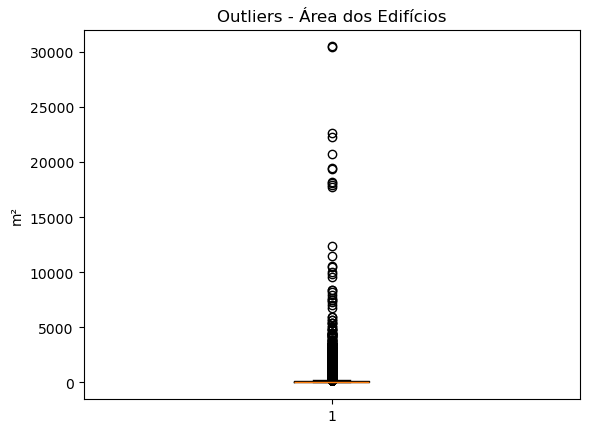

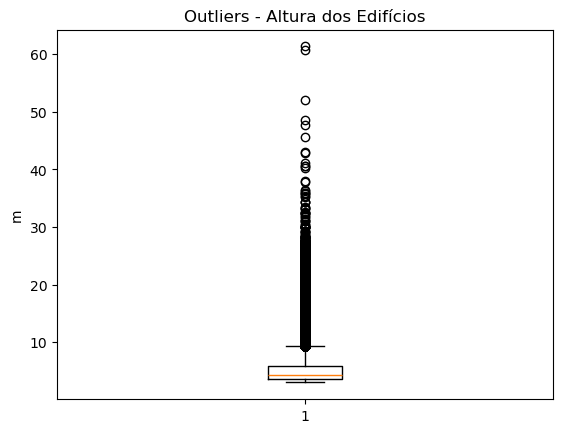


 Ficheiro de outliers exportado com sucesso!


In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar dados
gdf = gpd.read_file(r"C:\Users\gabri\OneDrive\Ambiente de Trabalho\Milestone2\raw\edificios.gpkg",
                    layer="ed12_polygons_all_with_heights_clean")

# 2. Selecionar variáveis
area = gdf["area_m2"]
altura = gdf["altura_edif_m"]


# MÉTODO 1 — IQR (RECOMENDADO)


def detectar_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    return (series < limite_inf) | (series > limite_sup), limite_inf, limite_sup

# Área
out_area, lim_inf_area, lim_sup_area = detectar_outliers_iqr(area)

# Altura
out_altura, lim_inf_alt, lim_sup_alt = detectar_outliers_iqr(altura)

# 3. Contagem
print("\n🔹 OUTLIERS (IQR)")
print(f"Área: {out_area.sum()} outliers")
print(f"Altura: {out_altura.sum()} outliers")

# 4. Guardar flags no GeoDataFrame
gdf["outlier_area"] = out_area
gdf["outlier_altura"] = out_altura


# MÉTODO 2 — Z-SCORE


def zscore(series):
    return (series - series.mean()) / series.std()

gdf["z_area"] = zscore(area)
gdf["z_altura"] = zscore(altura)

# threshold comum: |z| > 3
gdf["outlier_area_z"] = gdf["z_area"].abs() > 3
gdf["outlier_altura_z"] = gdf["z_altura"].abs() > 3

print("\n🔹 OUTLIERS (Z-score)")
print(f"Área: {gdf['outlier_area_z'].sum()} outliers")
print(f"Altura: {gdf['outlier_altura_z'].sum()} outliers")


# 5. VISUALIZAÇÃO (BOXPLOTS)


plt.figure()
plt.boxplot(area.dropna())
plt.title("Outliers - Área dos Edifícios")
plt.savefig('boxplot_outliers_area.png', dpi=300, bbox_inches='tight')
plt.ylabel("m²")
plt.show()

plt.figure()
plt.boxplot(altura.dropna())
plt.title("Outliers - Altura dos Edifícios")
plt.ylabel("m")
plt.savefig('boxplot_outliers_altura.png', dpi=300, bbox_inches='tight')
plt.show()


# 6. EXPORTAR OUTLIERS (OPCIONAL)


outliers = gdf[(gdf["outlier_area"]) | (gdf["outlier_altura"])]

outliers.to_file("outliers_edificios.geojson", driver="GeoJSON")

print("\n Ficheiro de outliers exportado com sucesso!")

A identificação de valores extremos nas variáveis area_m2 e altura_edif_m foi realizada através de uma abordagem combinada, utilizando o método do Intervalo Interquartil (IQR) e a análise de z-score.
Numa primeira fase, a aplicação do critério IQR permitiu identificar 5.225 outliers na área (5,9%) e 7.519 na altura (8,5%). Este número elevado deve-se à forte assimetria da distribuição dos dados, resultante da predominância de edifícios residenciais de pequena dimensão e da presença de um número reduzido de edifícios de grande escala, como industriais e equipamentos públicos.
Numa segunda fase, foi aplicada a análise de z-score (|z| > 3), permitindo isolar os casos mais extremos, reduzindo o conjunto para 477 observações na área e 1.717 na altura.


In [4]:
outliers_extremos = gdf[(gdf["z_area"].abs() > 3) | (gdf["z_altura"].abs() > 3)]

print(outliers_extremos[["area_m2", "altura_edif_m", "Layer"]].head())

      area_m2  altura_edif_m                 Layer
47      17.63      19.520000  ED08_EDIF_PERMANENTE
835   1174.09      11.980000  ED08_EDIF_PERMANENTE
3145    83.69      14.120001  ED08_EDIF_PERMANENTE
3146   118.29      14.120001  ED08_EDIF_PERMANENTE
9280   186.77      14.430000  ED08_EDIF_PERMANENTE


In [5]:
gdf.groupby("Layer")["area_m2"].describe()

,count,mean,std,min,25%,50%,75%,max
Layer,,,,,,,,
ED05_EDIF_ESCOLAR,650.0,269.532138,531.872848,2.07,25.1875,96.435,280.475,7530.74
ED06_EDIF_INDUSTRIAL,3031.0,585.960449,1607.294186,2.16,61.6100,203.170,550.130,30520.74
ED07_EDIF_NOTAVEL,518.0,317.428069,664.992235,2.05,25.4750,102.450,358.785,7925.11
ED08_EDIF_PERMANENTE,84309.0,66.969395,84.213887,2.00,15.8600,37.790,92.930,3170.79
ED10_EDIF_RELIGIOSA,141.0,197.858298,241.885671,4.51,53.0300,118.590,226.490,1460.52


A análise por tipologia confirmou uma elevada heterogeneidade dimensional, com valores médios e máximos significativamente superiores nos edifícios industriais, evidenciando distribuições assimétricas à direita (média superior à mediana).

In [6]:


# carregar dados
gdf = gpd.read_file(r"C:\Users\gabri\OneDrive\Ambiente de Trabalho\Milestone2\raw\edificios.gpkg",
                    layer="ed12_polygons_all_with_heights_clean")

# estatística por tipologia
stats_altura = gdf.groupby("Layer")["altura_edif_m"].describe()

print(stats_altura)

                        count      mean       std       min       25%  \
Layer                                                                   
ED05_EDIF_ESCOLAR       650.0  6.590123  3.595343  3.010000  3.987039   
ED06_EDIF_INDUSTRIAL   3031.0  6.785541  3.705434  3.009998  4.110001   
ED07_EDIF_NOTAVEL       518.0  7.864589  5.517438  3.050000  4.201648   
ED08_EDIF_PERMANENTE  84309.0  5.239627  2.805151  3.000648  3.639999   
ED10_EDIF_RELIGIOSA     141.0  9.579501  5.506836  3.059999  5.440000   

                           50%        75%        max  
Layer                                                 
ED05_EDIF_ESCOLAR     5.210000   8.100000  26.490002  
ED06_EDIF_INDUSTRIAL  5.959999   8.500000  61.339996  
ED07_EDIF_NOTAVEL     6.010000   9.862501  60.660004  
ED08_EDIF_PERMANENTE  4.250000   5.700000  52.020000  
ED10_EDIF_RELIGIOSA   8.440000  11.760000  27.790001  


Skew antes:
Área: 45.230107924413325
Altura: 3.4032772

Skew depois:
Área: 0.13351522760634316
Altura: 1.4729695


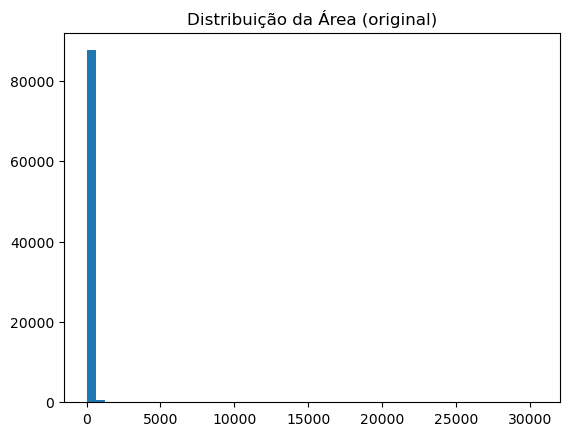

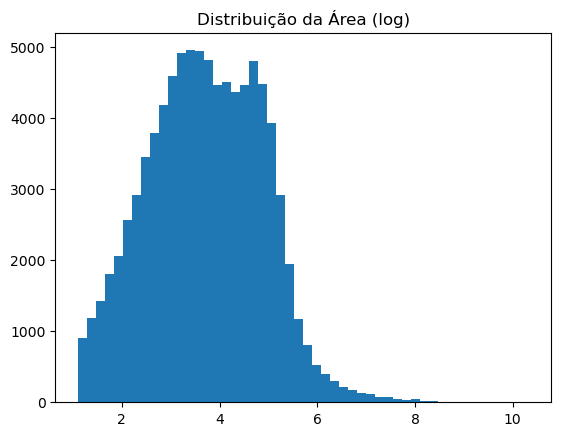

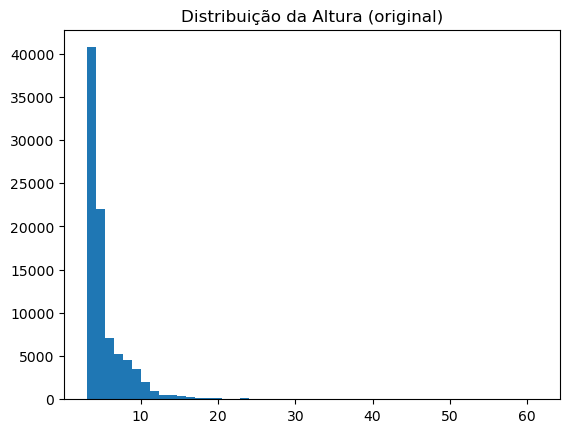

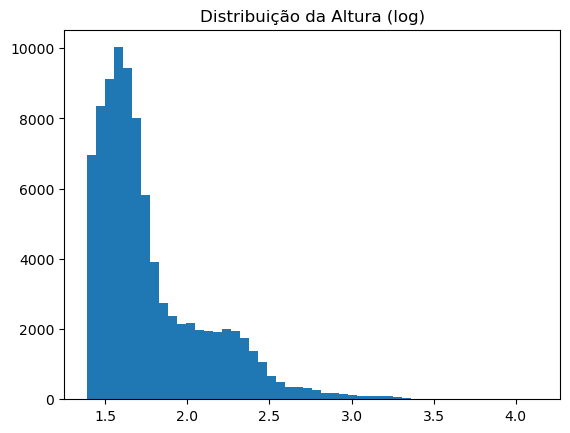

In [7]:
# skewness (assimetria)
skew_area = gdf["area_m2"].skew()
skew_altura = gdf["altura_edif_m"].skew()


# transformação logarítmica
gdf["log_area"] = np.log1p(gdf["area_m2"])
gdf["log_altura"] = np.log1p(gdf["altura_edif_m"])

print("Skew antes:")
print("Área:", gdf["area_m2"].skew())
print("Altura:", gdf["altura_edif_m"].skew())

print("\nSkew depois:")
print("Área:", gdf["log_area"].skew())
print("Altura:", gdf["log_altura"].skew())



# Área
plt.figure()
plt.hist(gdf["area_m2"], bins=50)
plt.title("Distribuição da Área (original)")
plt.savefig('distribuicao_area_(original).png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.hist(gdf["log_area"], bins=50)
plt.title("Distribuição da Área (log)")
plt.savefig('distribuicao_area_(log).png', dpi=300, bbox_inches='tight')
plt.show()

# Altura
plt.figure()
plt.hist(gdf["altura_edif_m"], bins=50)
plt.title("Distribuição da Altura (original)")
plt.savefig('distribuicao_altura_(original).png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.hist(gdf["log_altura"], bins=50)
plt.title("Distribuição da Altura (log)")
plt.savefig('distribuicao_altura_(log).png', dpi=300, bbox_inches='tight')
plt.show()

Como pudemos constatar anteriormente ambas as variáveis altura e área apresentam uma assimetria positiva sendo que no caso da altura esta assimetria é mais evidente (45.230) em comparação à altura que apresentou uma assimetria de ( 3.403). Esta assimetria é explicada, no caso da área dos edifícios, pelo facto de a esmagadora maioria dos edifícios serem do tipo residencial o que faz com que os mesmo tenham uma menor área em relação à edifícios do tipo industrial por exemplo. Em termos da altura, como Aveiro apresenta um grande número de infraestruturas industriais e marcos histórios esses edifícios normalmente se afastam do valor da média.

Efetou-se então uma transformação logarítmica para colmatar essas diferenças nos valores e como pudemos ver nos gráficos acima, em relação área dos edifícios consegui-se obter uma distribuição quase que normal (0.134) e já no caso da altura do edifício essa transformação permitiu obter o seguinte valor (1.473).

Em ambos os casos foi comprovado que houve uma melhora nos valores identificados como outliers e assim é possível realziar uma melhor análise comparativa dos resultados.

# Dataset Consumos

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import zscore
from scipy.stats import skew

In [9]:
# 1. Carregar os dados do ficheiro CSV

file_path = r"C:\Users\gabri\OneDrive\Ambiente de Trabalho\Milestone2\raw\consumoshorariocodigopostal3781a4420.csv"
df = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')
df_original = df.copy()

print("=== ESTRUTURA DOS DADOS ===")
print(df.dtypes)
print(f"\nTotal de registos: {len(df):,}")

=== ESTRUTURA DOS DADOS ===
Data/Hora                   object
Código Postal               object
Energia ativa (kWh)        float64
Data                        object
Hora                        object
Código Postal 4 Dígitos      int64
Código Postal 3 Dígitos      int64
dtype: object

Total de registos: 4,082,326


### Análise — Estrutura dos Dados de Consumo

O dataset de consumos horários apresenta **4.082.326 registos** com 7 variáveis, cobrindo fevereiro de 2024 para todos os códigos postais disponibilizados pela E-Redes.

A estrutura é bem definida e adequada para análise temporal:
- Data/Hora completo e colunas Data/Hora separadas facilitam o agrupamento horário e diário
- Código Postal a 7 dígitos permite granularidade máxima (nível de rua)
- Código Postal 4 Dígitos e Código Postal 3 Dígitos permitem agregações a escalas superiores
- Energia ativa (kWh) é a variável-alvo — consumo real medido nos contadores inteligentes


In [10]:
# 2. ESTATÍSTICA DESCRITIVA — Energia ativa (kWh)

kwh = df['Energia ativa (kWh)']

Q1    = kwh.quantile(0.25)
Q3    = kwh.quantile(0.75)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("\n=== ESTATÍSTICA DESCRITIVA — Energia ativa (kWh) ===")
print(f"  Mínimo             : {kwh.min():.4f} kWh/h")
print(f"  Máximo             : {kwh.max():.3f} kWh/h")
print(f"  Média              : {kwh.mean():.4f} kWh/h")
print(f"  Mediana            : {kwh.median():.4f} kWh/h")
print(f"  Desvio padrão      : {kwh.std():.4f} kWh")
print(f"  Q1 (25%)           : {Q1:.4f} kWh/h")
print(f"  Q3 (75%)           : {Q3:.4f} kWh/h")
print(f"  IQR                : {IQR:.4f}")
print(f"  Limite IQR inf     : {lower:.4f}")
print(f"  Limite IQR sup     : {upper:.4f}")
print(f"  Skewness original  : {skew(kwh):.3f}  (muito assimétrica)")


=== ESTATÍSTICA DESCRITIVA — Energia ativa (kWh) ===
  Mínimo             : 0.1740 kWh/h
  Máximo             : 21451.759 kWh/h
  Média              : 91.2390 kWh/h
  Mediana            : 40.8785 kWh/h
  Desvio padrão      : 468.6806 kWh
  Q1 (25%)           : 22.4058 kWh/h
  Q3 (75%)           : 77.4315 kWh/h
  IQR                : 55.0258
  Limite IQR inf     : -60.1329
  Limite IQR sup     : 159.9702
  Skewness original  : 29.870  (muito assimétrica)


###  Análise — Estatística Descritiva do Consumo Horário

Os resultados revelam uma distribuição fortemente assimétrica à direita, característica típica de dados de consumo energético urbano com mix heterogéneo de consumidores:

| Indicador | Valor | Interpretação |
|-----------|-------|---------------|
| Mínimo | 0,174 kWh/h | Consumidor muito reduzido (residencial noturno) |
| Máximo | 21.451,8 kWh/h | Grande consumidor industrial  |
| Média | 91,24 kWh/h | Fortemente inflacionada pelos valores extremos |
| **Mediana** | **40,88 kWh/h** | **Medida central mais robusta e representativa** |
| Desvio padrão | 468,68 kWh | Variabilidade extremamente elevada |
| IQR | 55,03 kWh/h | Dispersão da maioria dos dados |
| Limite IQR superior | ≈ 159,97 kWh/h | Limiar convencional de outlier |

A discrepância entre média (91,24) e mediana (40,88) é um indicador claro de assimetria positiva: poucos códigos postais com consumos muito elevados (zonas industriais/comerciais) inflacionam a média, enquanto a maioria dos CPs apresenta consumos moderados típicos de zona residencial.

Para o projeto CER, a mediana é a medida central mais adequada para caracterizar o consumo típico de um código postal. Os valores máximos registados (>1.000 kWh/h) correspondem provavelmente a grandes instalações industriais — precisamente os potenciais grandes consumidores que a CER pretende abastecer com o excedente fotovoltaico.

In [11]:
#import pandas as pd

#df = pd.read_csv(r"C:\Users\carol\OneDrive\Desktop\Carolina\Carolina\raw\consumoshorariocodigopostal3781a4420.csv", sep=";")

# Valores nulos por coluna
print(df.isnull().sum())

# Percentagem
print((df.isnull().mean() * 100).round(2))

# Linhas com nulos
print(df[df.isnull().any(axis=1)])

Data/Hora                  0
Código Postal              0
Energia ativa (kWh)        0
Data                       0
Hora                       0
Código Postal 4 Dígitos    0
Código Postal 3 Dígitos    0
dtype: int64
Data/Hora                  0.0
Código Postal              0.0
Energia ativa (kWh)        0.0
Data                       0.0
Hora                       0.0
Código Postal 4 Dígitos    0.0
Código Postal 3 Dígitos    0.0
dtype: float64
Empty DataFrame
Columns: [Data/Hora, Código Postal, Energia ativa (kWh), Data, Hora, Código Postal 4 Dígitos, Código Postal 3 Dígitos]
Index: []


### Análise — Missing Values nos Dados de Consumo

Em relação aos dados do Consumo, em todas as 7 colunas do dataset não foram encontrados missing values o que significa que não existem horas sem registos por código postal e com isso constata-se que não há necessidade de se realizar nenhuma imputação de valores pois o dataset está livre de valores em falta




## Outliers

In [12]:
# 3. IDENTIFICAÇÃO DE OUTLIERS (apenas Energia ativa)

mask_outliers = (kwh < lower) | (kwh > upper)
n_outliers = mask_outliers.sum()

print(f"\n=== OUTLIERS — Energia ativa (kWh) ===")
print(f"  Nº de outliers     : {n_outliers:,}  ({100*n_outliers/len(kwh):.2f}%)")
print(f"  Valor máximo       : {kwh.max():.3f} kWh/h")
print(f" Valores nulos     :\n{kwh.isnull().sum()}")
print()

#print("  Decisão: MANTER os outliers.")
#print("  Justificação: representam picos reais de consumo urbano,")
#print("  não erros de medição. Removê-los ou aplicar capping")
#print("  distorceria artificialmente a distribuição de carga.")


=== OUTLIERS — Energia ativa (kWh) ===
  Nº de outliers     : 351,480  (8.61%)
  Valor máximo       : 21451.759 kWh/h
 Valores nulos     :
0



### Análise — Outliers no Consumo Horário

Em relação aos outliers foram identificados 351.480 outliers (8,61% dos registos) utilizando o critério IQR convencional (Q3 + 1,5 × IQR ≈ 159,97 kWh/h), com valor máximo de 21.451,8 kWh/h.

Interpretação contextual dos outliers:

Este valor de 8,61% é esperado e metodologicamente justificável pelo contexto do projeto. O dataset agrega todos os tipos de consumidores (residenciais, comerciais, industriais e institucionais) num mesmo ficheiro. Um limiar único de 159,97 kWh/h é demasiado restritivo para um dataset tão heterogéneo:
- Um registo de 21.451,8 kWh/h equivale a ~25 MW de potência — o que representa um polo industrial ou subestação de grande dimensão, não uma anomalia de medição.
- Os CPs da zona de Cacia (indústria pesada) ou do centro comercial de Aveiro apresentam naturalmente consumos 100-200× superiores a uma habitação residencial.

Decisão de tratamento — sinalização sem remoção:

Os outliers indentificados não foram removidos pois os mesmo têm um grande valor no contexto do nosso projeto já que esses outliers acabam por representam potenciais consumidores , o que os tornam alvos prioritários à solução que o nosso projeto pretende entregar (CER). Estes outliers representam grandes consumidores de energia diurna que é o período de produção solar ma´xima e são os que mais beneficiariam da partilha do excedente fotovoltaico dos telhados residenciais vizinhos. Removê-los significaria eliminar a razão de estudo do nosso projeto.

Como não vamos eliminar estes outliers e os mesmos apresentam uma forte assimetria positiva, tivemos que realizar uma transformação logarítimica para reduzir o impacto destes valores extremos nas análises subsequentes.

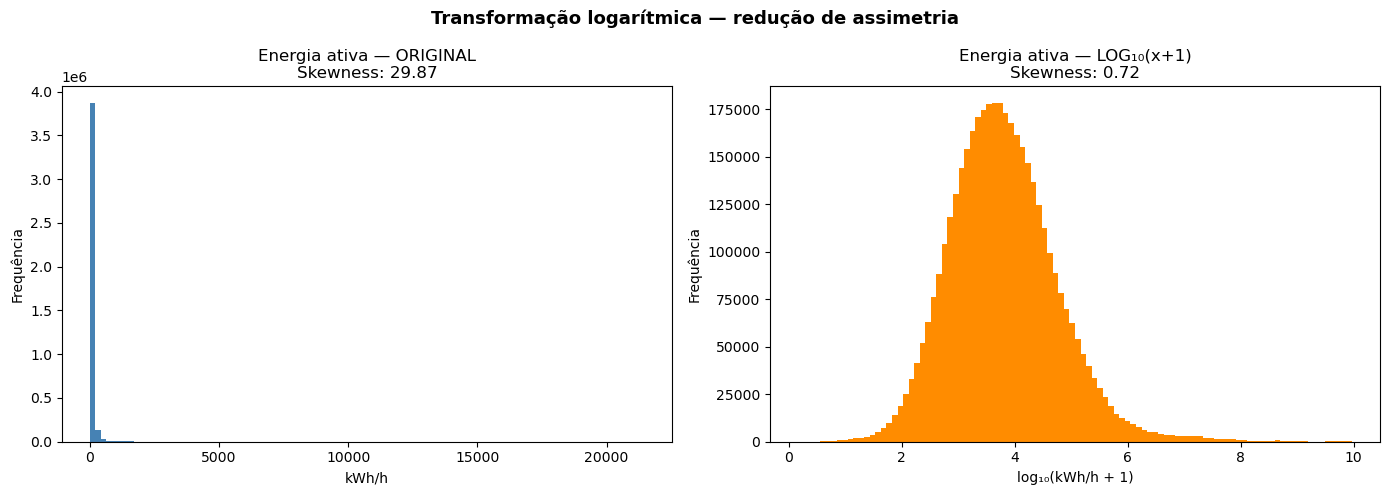

Figura guardada: fig_log_transformacao.png


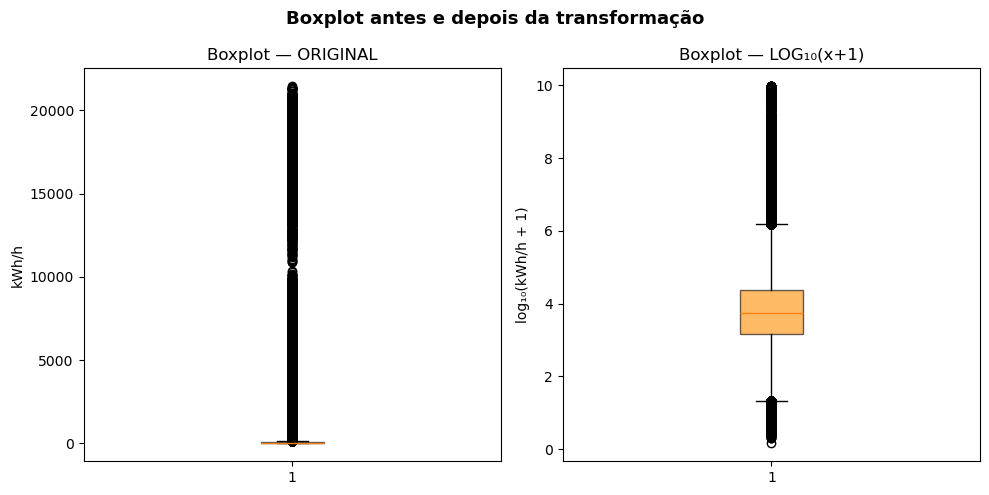

Figura guardada: fig_boxplot_log.png

=== TRANSFORMAÇÃO LOGARÍTMICA ===
  Skewness ANTES : 29.870
  Skewness DEPOIS: 0.725
  Redução de assimetria: 29.145

Ficheiro guardado: dados_tratados.csv
Colunas no ficheiro: ['Data/Hora', 'Código Postal', 'Energia ativa (kWh)', 'Data', 'Hora', 'Código Postal 4 Dígitos', 'Código Postal 3 Dígitos', 'Energia ativa (kWh)_log']


In [13]:

# 4. ANTES/DEPOIS DA TRANSFORMAÇÃO LOGARÍTMICA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(kwh, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title(f'Energia ativa — ORIGINAL\nSkewness: {skew(kwh):.2f}')
axes[0].set_xlabel('kWh/h')
axes[0].set_ylabel('Frequência')

kwh_log = np.log1p(kwh)
axes[1].hist(kwh_log, bins=100, color='darkorange', edgecolor='none')
axes[1].set_title(f'Energia ativa — LOG₁₀(x+1)\nSkewness: {skew(kwh_log):.2f}')
axes[1].set_xlabel('log₁₀(kWh/h + 1)')
axes[1].set_ylabel('Frequência')

plt.suptitle('Transformação logarítmica — redução de assimetria', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_log_transformacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig_log_transformacao.png")

# Boxplots antes/depois
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].boxplot(kwh, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6))
axes2[0].set_title('Boxplot — ORIGINAL')
axes2[0].set_ylabel('kWh/h')

axes2[1].boxplot(kwh_log, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='darkorange', alpha=0.6))
axes2[1].set_title('Boxplot — LOG₁₀(x+1)')
axes2[1].set_ylabel('log₁₀(kWh/h + 1)')

plt.suptitle('Boxplot antes e depois da transformação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_boxplot_log.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig_boxplot_log.png")


# 5. TRANSFORMAÇÃO LOGARÍTMICA 
#    Fórmula: log1p(x) = log(x + 1), evita log(0) quando x=0

df_transformed = df.copy()
df_transformed['Energia ativa (kWh)_log'] = np.log1p(df['Energia ativa (kWh)'])

print(f"\n=== TRANSFORMAÇÃO LOGARÍTMICA ===")
print(f"  Skewness ANTES : {skew(df['Energia ativa (kWh)']):.3f}")
print(f"  Skewness DEPOIS: {skew(df_transformed['Energia ativa (kWh)_log']):.3f}")
print(f"  Redução de assimetria: "
      f"{abs(skew(df['Energia ativa (kWh)']) - skew(df_transformed['Energia ativa (kWh)_log'])):.3f}")

# Guardar
df_transformed.to_csv("dados_tratados.csv", index=False)
print("\nFicheiro guardado: dados_tratados.csv")
print("Colunas no ficheiro:", df_transformed.columns.tolist())

### Análise — Resultado da Transformação Logarítmica

A transformação log₁p(x) = log(x + 1)produziu um resultado muito expressivo, já que permitiu obter uma assimetria de 0,725 valor muito inferior ao observado anteriormente nos dados originais (29,870):

| Métrica | Antes | Depois | Melhoria |
|---------|-------|--------|----------|
| Skewness (assimetria) | 29,870 | 0,725 |  97,6% |

Interpretação:

Uma skewness de 29,87 indica uma distribuição extremamente assimétrica — os valores extremos dominavam completamente a escala, tornando qualquer análise comparativa ou visualização pouco informativa. Após a transformação, a skewness de 0,725 enquadra-se no intervalo [-1, 1], considerado na literatura como aceitável para análise estatística.

Uma distribuição com skewness próxima de zero é mais adequada para os próximos passos do projeto:
- Comparação entre zonas — a normalização Z-score assume distribuição simétrica
- Clustering K-means — sensível a diferenças de escala entre variáveis
- Visualizações — histogramas e boxplots tornam-se legíveis e informativos
- Modelos preditivos — muitos algoritmos assumem aproximação à normalidade

Justificação de log₁p vs. log:
A fórmula log(x + 1) foi utilizada em detrimento de log pois a mesma permite contornar o caso de log(0), que seria matematicamente indefinido. Embora neste dataset o valor mínimo seja 0,174 kWh/h (sem zeros), a utilização de log₁p é o standard na literatura de análise de consumo energético por ser mais robusta.



In [14]:
# Guardar o consumo com a transformação logarítmica aplicada
# Supondo que a coluna transformada se chama 'consumo_log'
df_consumo_final.to_csv("consumo_aveiro_pre_processed.csv", index=False)

NameError: name 'df_consumo_final' is not defined